## Step 1 installation of R and jupyter
### Insatll R 4.5.x and Jupyter notebook
### Install jupyter R kernal by typing "install.packages("IRkernel")" inside R, and then by "IRkernel::installspec()" to registe R kernal in jupyter
## Step 2 install R package MMGS


In [ ]:
install.packages("devtools")
devtools::install_github("Ryougi-yukiro/MMGS") # it is an R package we developed for modelling genotype-phenotype map in multi-environment trial, available at https://github.com/Ryougi-yukiro/MMGS

## Step 3 load the pacakge and dataset 

In [3]:
library(MMGS)

Loading required package: ggplot2



### first the phenotype data


In [6]:
data(trait)

### This is a multi-environment sorghum breeding trial conducted across 7 sites (Fig. 1). Here,We have a genetic mapping population with roughly 250 individuals, derived from two inbreds. more information can be found at https://www.pnas.org/doi/full/10.1073/pnas.1718326115
### The phenotype data is stored in a table with 1659 rows and 6 columns,  
### the first column is sites codes,"PR12"  "IA14"  "PR11"  "IA13"  "PR14S" "KS11"  "KS12" each represent a physical location name of testing sites
### the second column is the population code; in this case, it will all be 1, since this is from one trial
### the third column is the individual ID
### the fourth column is flowering time, and the fifth colomn is also flowering time 
### the last column is site dummy code corresponding to the seven testing sites


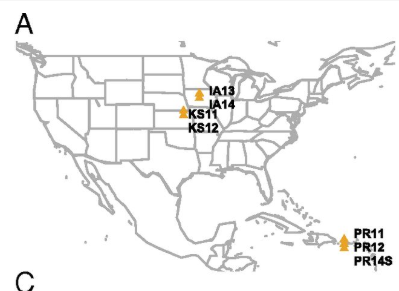

In [5]:
head(trait)

,env_code,pop_code,line_code,FTdap,FTgdd,env_note
,<chr>,<int>,<chr>,<dbl>,<dbl>,<int>
1,PR12,1,E5,58.1071,1544.069,2
2,PR12,1,E6,59.2582,1575.221,2
3,PR12,1,E7,56.1885,1492.151,2
4,PR12,1,E8,56.1885,1492.151,2
5,PR12,1,E9,63.0955,1671.440,2
6,PR12,1,E10,53.1187,1409.773,2


### Second, environment information is stored in a data.frame with the following columns:
### env_note Environmental note assigned to each environment. 
### env_code Environmental code assigned to each environment. 
### lat Latitude of the environment. lon Longitude of the environment. 
### PlantingDate Planting Date of lines. 
### TrialYear Planting Year of lines 
### Location Location of the environment.



In [11]:
data(env_info)
env_info

env_notes,env_code,lat,lon,PlantingDate,TrialYear,Location
<int>,<chr>,<dbl>,<dbl>,<chr>,<int>,<chr>
1,PR11,18.0373,-66.7963,2010-12-04,2010,PR
2,PR12,18.0373,-66.7963,2011-12-12,2011,PR
3,KS11,39.1836,-96.5717,2011-06-08,2011,KS
4,KS12,39.1836,-96.5717,2012-06-07,2012,KS
5,IA13,42.0308,-93.6319,2013-06-05,2013,IA
6,IA14,42.0308,-93.6319,2014-06-10,2014,IA
7,PR14S,18.0373,-66.7963,2014-06-05,2014,PR


### Third， genotype data 
### The genotype data is a data.frame of dimensions 237 × 1463, representing 237 individuals and 1463 SNP variant sites.
### The first column contains individual names ranging from E5 to E248, with the data type being character (chr). 
### Starting from the second column, the column names follow the format "chromosome_position". For example, S1_1857181 represents position 1857181 bp on chromosome S1.
### In the genotype table, the value 1 represents a homozygous major variant (AA）, 0 represents a heterozygous variant(Aa), and -1 represents a homozygous minor allele (aa), with the data type being integer (int)

In [13]:
data(geno)
geno

line_code,S1_1857181,S1_1857180,S1_1857182,S1_1857183,S1_1857184,S1_2634344,S1_4119134,S1_4049199,S1_3773767,⋯,S10_58621095,S10_4076534,S10_4076537,S10_4076540,S10_59030462,S10_59438902,S10_59576628,S10_59609270,S10_59885614,S10_60232151
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
E5,1,1,1,1,1,1,-1,-1,-1,⋯,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
E6,1,1,1,1,1,1,1,1,1,⋯,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
E7,-1,-1,-1,-1,-1,-1,-1,-1,-1,⋯,1,1,1,1,1,1,1,1,1,1
E8,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,-1,-1,-1,1,1
E9,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
E10,-1,-1,-1,-1,-1,-1,-1,-1,-1,⋯,1,1,1,1,1,1,1,1,1,1
E11,1,1,1,1,1,1,-1,-1,-1,⋯,1,1,1,1,1,1,1,1,1,1
E12,-1,-1,-1,-1,-1,-1,-1,-1,-1,⋯,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
E13,-1,-1,-1,-1,-1,-1,-1,-1,-1,⋯,1,1,1,1,1,1,1,1,-1,-1


### fourth environment data is stored in the data frame
### env_code Environmental code assigned to each environment. 
### Date Date of the environmental information. 
### Tmax Environmental parameter related to the maximum temperature. 
### Tmin Environmental parameter related to the minimum temperature. 
### DL Environmental parameter related to Day Length. 
### GDD Environmental parameter related to Growing Degree Days-a measure of heat accumulation used to estimate growth stages and maturity dates for plants and insects. Calculated by summing daily temperatures above a specific base threshold, GDD helps predict development phases (e.g., emergence, flowering, harvest) more accurately than calendar days.
### PTT Environmental parameter related to Photothermal Time- an environmental index quantifying plant development by combining temperature—specifically growing degree-days (GDD)—with daily photoperiod (sunlight hours). It represents the cumulative time a plant needs to pass through developmental stages, such as flowering, based on heat and light cues.
### PTR Environmental parameter related to Photothermal Ratio- expressed as the ratio of radiant energy (light) to thermal energy (temperature) in plant studies, describing the light energy available for photosynthesis per unit of developmental time
### PTS Environmental parameter related to Photothermal spectroscopy -a highly sensitive, non-destructive analytical technique that measures heat generated when plant tissues absorb light, allowing researchers to study physiological processes like photosynthesis in real-time.

In [16]:
data(PTT_PTR)
head(PTT_PTR)

,env_code,Date,Tmax,Tmin,DL,GDD,PTT,PTR,PTS
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,PR11,20101204,84.2,69.8,11.88,27.0,320.760,2.272727,312979.6
2,PR11,20101205,86.0,62.6,11.90,24.3,289.170,2.042017,492412.0
3,PR11,20101206,87.8,64.4,11.88,26.1,310.068,2.196970,502647.3
4,PR11,20101207,84.2,71.6,11.87,27.9,331.173,2.350463,276591.9
5,PR11,20101208,86.0,73.4,11.87,29.7,352.539,2.502106,282983.0
6,PR11,20101209,87.8,71.6,11.87,29.7,352.539,2.502106,363835.2


## Step 4 Data processing and visulisation
### Summary statistics of the phenotype for each environment.Input is trait dataframe 
### output is the env_trait dataframe with 7 rows(sites) × 5 columns. mean: The mean FTgdd value of all lines within that environment. q25 / q75: The first (25%) and third (75%) quartiles. n_obs: The number of individuals observed in each environment


In [18]:
env_trait<-env_trait_calculate(data=trait,trait="FTgdd",env="env_code")
env_trait

env_code,mean,q25,q75,n_obs
<chr>,<dbl>,<dbl>,<dbl>,<int>
IA13,1859.120,1757.380,1953.093,237
IA14,1550.804,1487.607,1608.957,237
KS11,2289.254,1949.960,2570.410,237
KS12,2459.633,2144.290,2786.790,237
PR11,1556.628,1478.145,1618.024,237
PR12,1507.464,1470.345,1533.686,237
PR14S,1937.385,1735.940,2076.320,237


### format the phenotype value for each trait and line by sites
### Input is trait dataframe
### output is a matrix of FTgdd phenotypic values, where rows represent lines and columns represent environments. Row names are line_code (E10 through E248, 237 lines in total). Column names are the seven environment codes: PR12, IA14, PR11, IA13, PR14S, KS11, KS12.

In [21]:
LbyE<-LbyE_calculate(data=trait,trait="FTgdd",env="env_code",line="line_code")
head(LbyE)

,line_code,PR12,IA14,PR11,IA13,PR14S,KS11,KS12
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,E10,1409.773,1634.379,1464.711,2037.960,2669.580,2928.190,3080.69
2,E100,1595.988,1634.379,1830.610,1863.785,2052.270,2152.050,2229.57
3,E101,1512.918,1579.939,1606.170,1845.605,2092.020,2525.090,2693.47
4,E102,1502.535,1438.680,1488.024,1734.530,1926.199,2285.579,2315.11
5,E103,1428.118,1645.410,1501.458,2097.980,2505.720,3307.950,3467.31
6,E104,1502.535,1525.499,1464.711,1963.830,2076.320,3143.210,2881.29


### have a look at the phenotypic correlation  between different environments and visualise using a heatmap.

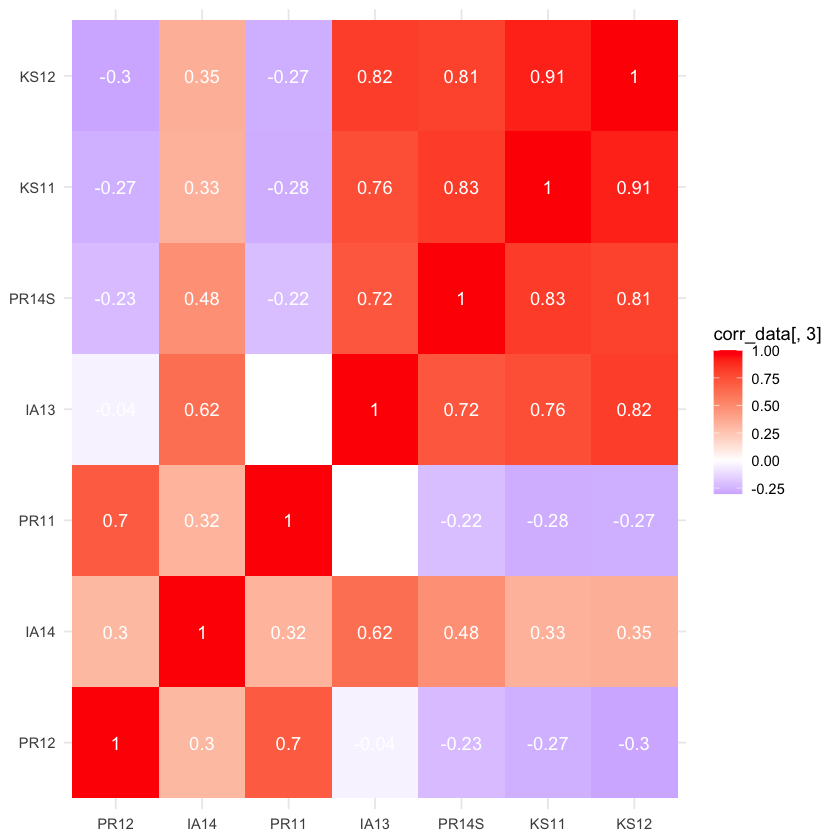

In [23]:
LbyE_corrplot(LbyE=LbyE,cor_type="heatmap",color=c("blue","white","red"))

In [25]:
### convert the wide-format line-by-environment phenotypic matrix into long format.
etl <- LbyE_Reshape(data = env_trait, LbyE = LbyE, env = "env_code")
head(etl)

,env_code,trait,line
,<chr>,<dbl>,<chr>
1,PR12,1409.773,E10
2,IA14,1634.379,E10
3,PR11,1464.711,E10
4,IA13,2037.960,E10
5,PR14S,2669.580,E10
6,KS11,2928.190,E10


### visualizes the distribution of phenotypic values across environments, along with the environment‑specific mean and quartiles.

### X‑axis: environments; Y‑axis: trait value (e.g., FTgdd). Grey points: phenotypic values of each line in each environment. Grey lines: reaction norms of individual lines across environments. Red line: environment means. Black lines: environment‑specific Q25 and Q75. Grey shaded area: range from Q25 to Q75, representing the middle 50% of the lines.

### The plot helps to quickly identify environments with high means, large variation, and whether lines respond consistently across environments.

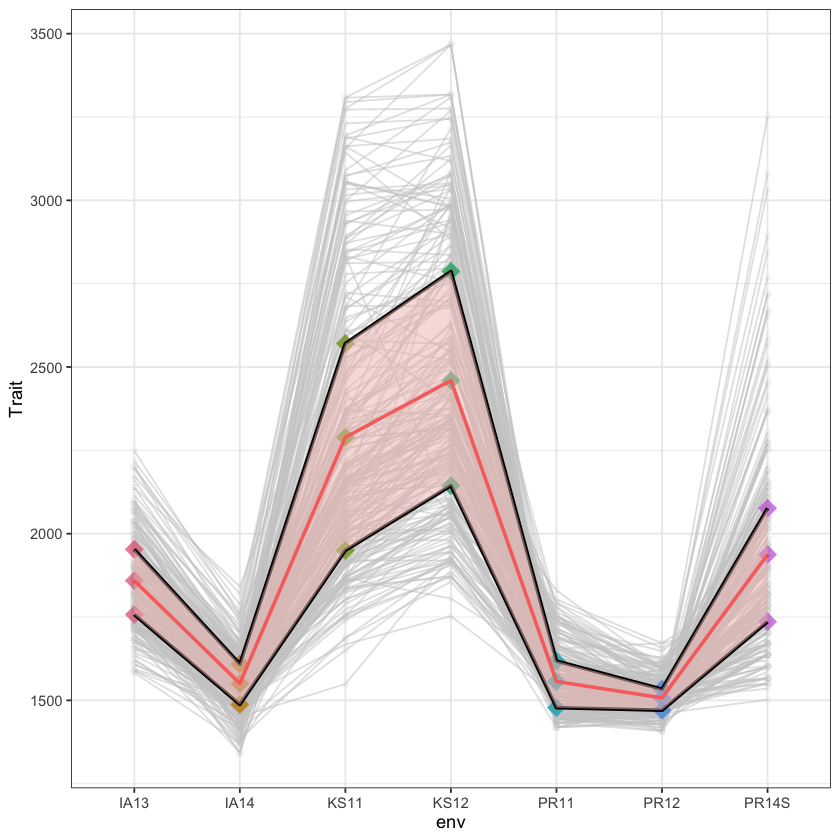

In [26]:
etl_plotter(data = etl, trait = env_trait)

### performs an exhaustive search over time windows to identify the environmental covariates most highly correlated with the trait mean.

### Input data: environment summary table (env_trait) env_paras: daily environmental covariate data for each environment (2.2 PTT_PTR), including env_code and daily values of the covariates. searching_daps: reference length for the search window (default used with dap_x and dap_y). p: population code dap_x, dap_y: start and end days for the search LOO: whether to use leave‑one‑out cross‑validation (0 = no, otherwise median is used). Paras: vector of environmental covariate names ("DL","GDD","PTT","PTR","PTS").

### Output: A matrix where each row represents a time window. Columns include: pop_code, Day_x (window start), Day_y (window end), window (length), each covariate the correlation (R_ prefix) and its negative (nR_ prefix).

In [28]:
Paras <- c('DL', 'GDD', 'PTT', 'PTR', 'PTS')
pop_cor <- Exhaustive_search(data = env_trait, env_paras = PTT_PTR,
                             searching_daps = 80, p = 1, 
                             dap_x = 80, dap_y = 80, LOO = 0, Paras = Paras)
head(pop_cor)

pop_code,Day_x,Day_y,window,R_DL,R_GDD,R_PTT,R_PTR,R_PTS,nR_DL,nR_GDD,nR_PTT,nR_PTR,nR_PTS
1,1,7,6,0.5607,0.2744,0.6200,-0.0738,0.7795,-0.5607,-0.2744,-0.6200,0.0738,-0.7795
1,1,8,7,0.5607,0.2943,0.6414,-0.0664,0.7739,-0.5607,-0.2943,-0.6414,0.0664,-0.7739
1,1,9,8,0.5610,0.2910,0.6637,-0.0896,0.7841,-0.5610,-0.2910,-0.6637,0.0896,-0.7841
1,1,10,9,0.5611,0.2876,0.6895,-0.1175,0.7973,-0.5611,-0.2876,-0.6895,0.1175,-0.7973
1,1,11,10,0.5611,0.2793,0.7101,-0.1386,0.7780,-0.5611,-0.2793,-0.7101,0.1386,-0.7780
1,1,12,11,0.5611,0.2948,0.7260,-0.1349,0.7711,-0.5611,-0.2948,-0.7260,0.1349,-0.7711


In [29]:
# identify the best window and output the correleation
best <- pop_cor[which.max(abs(pop_cor[,"R_PTT"])), ]
best_Day_x <- best["Day_x"]
best_Day_y <- best["Day_y"]
best_R <- best["R_PTT"]

cat("Best window:", best_Day_x, "to", best_Day_y, "with R =", best_R)

Best window: 18 to 43 with R = 0.9965

### calculates the mean of each environmental covariate over a specified time window for every environment and merges them into the environment summary table.
### Input: data: environment summary table (e.g., env_trait) containing env_code, mean, q25, q75, n_obs, etc. env_paras: daily environmental covariate data (e.g., PTT_PTR) including env_code and daily values for DL, GDD, PTT, PTR, PTS. max_d1, max_d2: start and end days of the time window (default 18 and 43).
### Output: A data frame (envMeanPara) that extends env_trait with additional columns for each covariate’s mean over the specified window (e.g., DL, GDD, PTT, PTR, PTS). In the example output, each row corresponds to one environment and includes both the original summary statistics and the new covariate means.

In [31]:
envMeanPara <- EPM(data = env_trait, env_paras = PTT_PTR,
                   max_d1 = best_Day_x, max_d2 = best_Day_y)
envMeanPara

mean,env_code,q25,q75,n_obs,DL,GDD,PTT,PTR,PTS
<dbl>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1507.464,PR12,1470.345,1533.686,237,11.9250,27.1385,323.6154,2.2759,355766.1
1550.804,IA14,1487.607,1608.957,237,16.1562,20.1346,325.1575,1.2469,658656.1
1556.628,PR11,1478.145,1618.024,237,11.8781,27.0000,320.7250,2.2730,344680.7
1859.120,IA13,1757.380,1953.093,237,16.2765,25.3077,411.9240,1.5549,807840.7
1937.385,PR14S,1735.940,2076.320,237,13.9669,31.5000,439.9730,2.2553,338772.8
2289.254,KS11,1949.960,2570.410,237,15.8319,33.4173,528.7473,2.1122,1010999.9
2459.633,KS12,2144.290,2786.790,237,15.8373,35.1000,555.9994,2.2160,1086316.0


### filters on dataset to ensure that the phenotype and genotype datasets contain exactly the same set of lines for downstream genomic prediction analyses.

In [32]:
pheno<-LbyE[which(as.character(LbyE$line_code)%in%
                    c("line_code",as.character(geno$line_code))),]
head(pheno)

,line_code,PR12,IA14,PR11,IA13,PR14S,KS11,KS12
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,E10,1409.773,1634.379,1464.711,2037.960,2669.580,2928.190,3080.69
2,E100,1595.988,1634.379,1830.610,1863.785,2052.270,2152.050,2229.57
3,E101,1512.918,1579.939,1606.170,1845.605,2092.020,2525.090,2693.47
4,E102,1502.535,1438.680,1488.024,1734.530,1926.199,2285.579,2315.11
5,E103,1428.118,1645.410,1501.458,2097.980,2505.720,3307.950,3467.31
6,E104,1502.535,1525.499,1464.711,1963.830,2076.320,3143.210,2881.29


## Step 5 data analysis
###  RN model The MMGP function is called to perform cross‑environment genomic prediction using a reaction norm (RN) framework combined with ridge regression BLUP (rrBLUP). It quantifies genotype‑by‑environment interaction (G×E) and evaluates prediction accuracy within and across environments through repeated cross‑validation.

### Main inputs: pheno: from last step geno: the loaded genotype data geno is already filtered, env: environment information data frame (from previous step env_info) para: data frame with environmental covariates (step 3.7 EPM) Para_Name: name of the environmental index used as the gradient (here "PTT"). model="rrBLUP": genomic prediction model (mixed model with random marker effects). you can also chose different model (rrBLUP, LASSO,EN,RR,BA,BB,BC,BL,BRR,RKHS,MKRKHS,SVM,RF and LightGBM). depend="Norm": standard reaction norm approach (intercept+slope prediction). fold=2: 2‑fold cross‑validation. reshuffle=5: 5 random partitions. methods="RM.G": reaction norm → estimate intercept and slope for each line, then predict them using genomic data.

### Output: out[[1]]: data frame with observed (obs), predicted (pre), colour (col), and environment (para). 1659 rows (237 lines × 7 environments). out[[2]]: matrix (5 rows × 7 columns) of within‑environment prediction correlations (Pearson r) for each reshuffle. out[[3]]: numeric vector (length 5) of across‑environment overall prediction correlations.

In [35]:
out<-MMGP(pheno=pheno,geno=geno,env=env_info,
          para=envMeanPara,Para_Name="PTT",model="rrBLUP",
          depend="Norm",fold=2,reshuffle=5,methods="RM.G",
          ms1=2,ms2=2)

head(out[[1]])
apply(out[[2]],2,mean)bb
mean(out[[3]])

,obs,pre,col,para
,<dbl>,<dbl>,<chr>,<chr>
1,1595.988,1584.780,#FF0000,PR12
2,1502.535,1493.653,#FF0000,PR12
3,1428.118,1497.512,#FF0000,PR12
4,1502.535,1497.745,#FF0000,PR12
5,1523.302,1535.623,#FF0000,PR12
6,1544.069,1516.229,#FF0000,PR12


PR12      IA14      PR11      IA13     PR14S      KS11      KS12 
0.5951556 0.4051816 0.5727253 0.4782756 0.4765328 0.6175661 0.6381952

[1] 0.8728197

###  In breed applications, we usually have a large number of lines got genotyped but only a small fraction of them are phenotyped. This means the input pheno data.frame will contain missing value for many sites. In practice, once we have out[[1]], where the predicted and measured phenotypes were stored. we rank the predicted value at each sites and select elite materials from the top rank.

In [36]:
### PEI model The function MMPrdM (which is the depend = "PEI" branch of MMGP) is called to perform genomic prediction across environments using the Polygenic Environmental Interaction (PEI) framework. Unlike the reaction norm (RN) approach, PEI directly models genotype-by-environment interaction at the marker level. With model = "rrBLUPJ" and depend = "PEI", it first estimates marker effects for each environment separately, then regresses these marker effects on the environmental index (e.g., PTT) to predict phenotypes in any environment (including those not observed). The output provides fitted values and within‑environment correlations.

### Input: env: environment information data frame (step 2.4 env_info) para: data frame with environmental covariates (step 3.7 EPM) env: environment information data frame (not directly used here but required for matching). para: data frame with environmental covariates, 3.7 EPM Para_Name: name of the environmental index column (e.g., "PTT"). model = "rrBLUPJ": use mixed.solve to estimate marker effects per environment. you can also chose different model (rrBLUP, LASSO,EN,RR,BA,BB,BC,BL,BRR,RKHS,MKRKHS,SVM,RF and LightGBM). depend = "PEI": activate the PEI framework. reshuffle = 2: number of repetitions (the code runs the procedure 2 times; here it likely does not involve cross‑validation but repeated fitting, returning averaged correlations).

### Output: out[[1]]: data frame with observed (obs), predicted (pre), colour (col), and environment (para). 1659 rows (237 lines × 7 environments). out[[2]]: matrix (5 rows × 7 columns) of within‑environment prediction correlations (Pearson r) for each reshuffle. out[[3]]: numeric vector (length 5) of across‑environment overall prediction correlations.

In [37]:
out2<-MMPrdM(pheno=pheno,geno=geno,
            env=env_info,para=envMeanPara,
            model="rrBLUPJ",depend="PEI",
            Para_Name="PTT",reshuffle=2)

mean(out2[[3]])
apply(out2[[2]],2,mean)
head(out2[[1]])

[1] 0.9494913

PR12      IA14      PR11      IA13     PR14S      KS11      KS12 
0.6996221 0.6543900 0.7063727 0.8053814 0.7997450 0.8963921 0.9200799

,obs,pre,col,para
,<dbl>,<dbl>,<chr>,<chr>
1,1409.773,1508.553,#FF0000,PR12
2,1595.988,1623.116,#FF0000,PR12
3,1512.918,1544.909,#FF0000,PR12
4,1502.535,1503.963,#FF0000,PR12
5,1428.118,1506.447,#FF0000,PR12
6,1502.535,1511.336,#FF0000,PR12


[1] TRUE